<a href="https://colab.research.google.com/github/Fei-Q/dsst389/blob/main/nb/notebook11a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Notebook11a

### Setup

Run all of the following before starting the notebook.

In [1]:
! wget -q -nc https://raw.githubusercontent.com/taylor-arnold/fds-py/refs/heads/main/funs.py

In [2]:
import numpy as np
import polars as pl

from funs import *
from plotnine import *
from polars import col as c
theme_set(theme_minimal())

ub = "https://raw.githubusercontent.com/taylor-arnold/fds-py-nb/refs/heads/main/"

In [3]:
metro = pl.read_csv(ub + "data/acs_cbsa.csv")
docs = pl.read_csv(ub + "data/wiki_senator_class_docs.csv")
meta = pl.read_csv(ub + "data/wiki_senator_class.csv")
anno = pl.read_csv(ub + "data/wiki_senator_class_anno.csv")

## Part I: Classify Household Income

1. Start by building a model object that uses linear regression to predict the household median income using the 1 bedroom median rent. Save the model as an object `model`.

In [4]:
model = (
    metro
    .pipe(
        DSSklearn.linear_regression,
        target=c.hh_income_median,
        features=[c.rent_1br_median]
    )
)

2. Compute the score of the model object. This is easy, but take a moment to make sure you understand what this means.

In [5]:
model.score()

{'train': np.float64(8142.396015438644),
 'test': np.float64(7625.9325036243645)}

3. Take the `metro` data and direclty comput the root mean squared error (RMSE) without using the `.score()` method. Verify that it matches what you had in the previous question.

In [6]:
(
    metro
    .with_columns(
        model.predict()
    )
    .group_by(c.index_)
    .agg(
        rmse = (c.target_ - c.prediction_).pow(2).mean().sqrt()
    )
)

index_,rmse
str,f64
"""train""",8142.396015
"""test""",7625.932504


4. Print out the coefficents from the model. Make sure you understand what these mean and how they relate to the notes from today.

In [7]:
model.coef()

name,param
str,f64
"""Intercept""",58053.966309
"""rent_1br_median""",10790.62407


5. Redefine `model` to be a linear regression predicting household median income using three variables: 1BR median rent, the percentage of income used for rent, and the percentage of people who own their homes.

In [8]:
model = (
    metro
    .pipe(
        DSSklearn.linear_regression,
        target=c.hh_income_median,
        features=[c.rent_1br_median, c.rent_perc_income, c.percent_own]
    )
)

6. Compute the score of this model (you may use `.score()` again). Visually compare to the model with just one predictor.

In [9]:
model.score()

{'train': np.float64(6093.508695623027), 'test': np.float64(5888.108871113693)}

7. Look at the coefficents of the new model. What do their signs tell us about the relationship between these three predictor variables and the household median income?

In [10]:
model.coef()

name,param
str,f64
"""Intercept""",58053.966309
"""rent_1br_median""",12634.805069
"""percent_own""",2643.059009
"""rent_perc_income""",-4154.172845


8. Next, redefine `model`. We will still predict household median income using 1BR median rent, percentage spent on housing, and percentage of people owning their house. But, now use the `DSSklearn.elastic_net_cv` model.

In [11]:
model = (
    metro
    .pipe(
        DSSklearn.elastic_net_cv,
        target=c.hh_income_median,
        features=[c.rent_1br_median, c.rent_perc_income, c.percent_own]
    )
)

9. Look at the coefficents of the elastic net model. You should see that they are much smaller in magnitude than the logistic regression model.

In [12]:
model.coef()

name,param
str,f64
"""Intercept""",58053.966309
"""rent_1br_median""",920.125314
"""percent_own""",134.704858
"""rent_perc_income""",-129.673977


10. Look at the score of the model. It's not very good (probably) because the cross-validation system is not optimized for models this small. We would need to modify some inputs to get better values.

In [13]:
model.score()

{'train': np.float64(12763.892437258282),
 'test': np.float64(11649.508807154587)}

## Part II: Classify Region

11. Now, use logistic regression to predict the quadrant (`quad`) that a region is from using the density, percentage owned, and household median income. Save the model again as `model`.

In [14]:
model = (
    metro
    .pipe(
        DSSklearn.logistic_regression,
        target=c.quad,
        features=[c.density, c.percent_own, c.hh_income_median]
    )
)

12. Now look at the coefficents of the model. Try your best to make some sense of them.

In [15]:
model.coef()

name,NC,NE,O,S,W
str,f64,f64,f64,f64,f64
"""Intercept""",1.024809,-0.199085,-2.477352,1.383248,0.268379
"""density""",-0.228505,0.471024,0.859141,0.178963,-1.280623
"""percent_own""",0.419955,0.689729,0.044428,-0.384191,-0.769921
"""hh_income_median""",0.34041,0.469976,-1.472732,-0.571746,1.234093


13. Compute the scores for this model. Make sure you understand what these numbers represent! Hint: It's easier to understand than in the previous examples.

In [16]:
model.score()

{'train': 0.5727411944869831, 'test': 0.5693950177935944}

14. Print out the confusion matrix. Make sure you also understand what it represents.

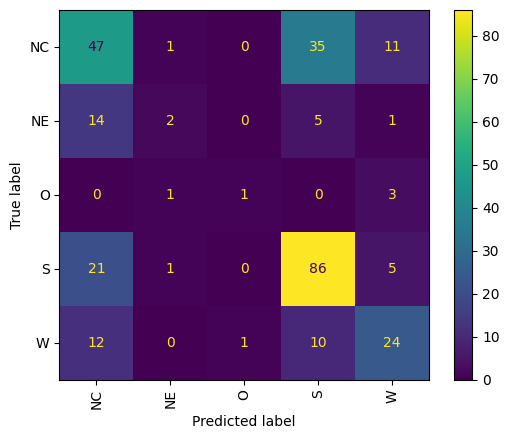

In [17]:
model.confusion_matrix()

## Part III: Text Analysis

15. Let's load in the annotation data from the sentator dataset we built previously. (This code and the remaining ones I have already filled in for you)

In [18]:
anno = (
    anno
    .join(meta.select(c.doc_id, c.party), on=c.doc_id)
)
anno

doc_id,sid,tid,token,token_with_ws,lemma,upos,tag,is_alpha,is_stop,is_punct,dep,head_idx,ent_type,ent_iob,party
str,i64,i64,str,str,str,str,str,bool,bool,bool,str,i64,str,str,str
"""Tommy Tuberville""",1,1,""" """,""" """,""" ""","""SPACE""","""_SP""",false,false,false,"""dep""",2,"""""","""O""","""Republican"""
"""Tommy Tuberville""",1,2,"""Thomas""","""Thomas ""","""Thomas""","""PROPN""","""NNP""",true,false,false,"""compound""",4,"""PERSON""","""B""","""Republican"""
"""Tommy Tuberville""",1,3,"""Hawley""","""Hawley ""","""Hawley""","""PROPN""","""NNP""",true,false,false,"""compound""",4,"""PERSON""","""I""","""Republican"""
"""Tommy Tuberville""",1,4,"""Tuberville""","""Tuberville ""","""Tuberville""","""PROPN""","""NNP""",true,false,false,"""nsubj""",14,"""PERSON""","""I""","""Republican"""
"""Tommy Tuberville""",1,5,"""(""","""(""","""(""","""PUNCT""","""-LRB-""",false,false,true,"""punct""",4,"""""","""O""","""Republican"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Cynthia Lummis""",184,13,"""Synod""","""Synod ""","""Synod""","""PROPN""","""NNP""",true,false,false,"""appos""",10,"""""","""O""","""Republican"""
"""Cynthia Lummis""",184,14,"""(""","""(""","""(""","""PUNCT""","""-LRB-""",false,false,true,"""punct""",13,"""""","""O""","""Republican"""
"""Cynthia Lummis""",184,15,"""LCMS""","""LCMS""","""LCMS""","""PROPN""","""NNP""",true,false,false,"""appos""",13,"""""","""O""","""Republican"""


16. We can fit a penalised logistic model using the term-frequency matrix by calling the function `DSSklearnText.logistic_regression_cv`. It works just like the logistic regression model above, but accepts an annotation object and does the creation of the TF matrix internally for us. We will do more with these in future notebooks.

In [19]:
model =(
    anno
    .pipe(
        DSSklearnText.logistic_regression_cv,
        doc_id=c.doc_id,
        term_id=c.lemma,
        target=c.party,
        solver="saga",
        min_df=0.05,
        l1_ratios=[1]
    )
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1863: UserWarning: l1_ratios parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
/usr/local/lib/python

17. Look at the confusion matrix:

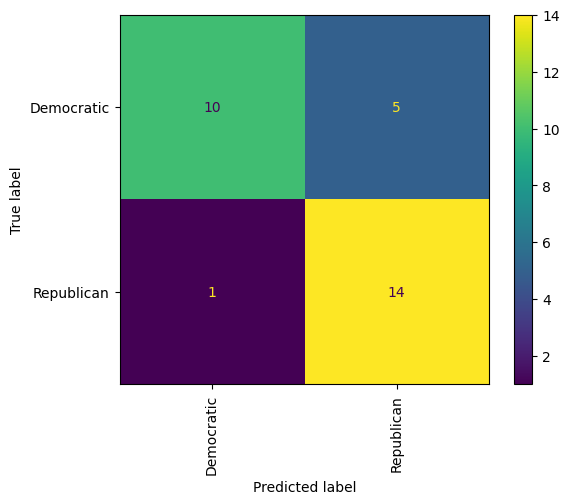

In [20]:
model.confusion_matrix()

18. Finally, look at the non-zero coefficents. Notice that the table has a very specific (where Republican values are all the negative of the Democratic ones) due to the way the data is balanced between the categories.

In [21]:
(
    model
    .coef()
    .with_columns(cs = c.Democratic.abs() + c.Republican.abs())
    .filter(c.cs > 0)
    .sort(c.Democratic)
)

name,Democratic,Independent,Republican,cs
str,f64,f64,f64,f64
"""Republican""",-0.001218,-0.000127,0.001345,0.002563
"""republican""",-0.001199,-0.000077,0.001275,0.002474
"""reject""",-0.001116,0.000054,0.001061,0.002177
"""conservative""",-0.001049,-0.00003,0.001079,0.002129
"""Mitch""",-0.001014,-0.000023,0.001036,0.00205
…,…,…,…,…
"""neighborhood""",0.001134,-0.000006,-0.001128,0.002263
"""public""",0.001166,0.000033,-0.001199,0.002364
"""bomb""",0.00117,-0.000078,-0.001092,0.002262
